# Anomaly Detection Evaluation: BYOL Features — Multi-Method Benchmark

This notebook benchmarks multiple anomaly detection strategies on the MGCLS dataset using BYOL-extracted features.
It compares:
- **Baseline**: PCA scores from Protege catalogue
- **Moment Pooling (L2)**: dimensionality reduction via statistical moments
- **Moment Pooling + Isolation Forest**
- **Moment Pooling + Extended Isolation Forest (EIF)**  ← new, from arXiv:2110.13402
- **Moment Pooling + ECOD** ← statistical anomaly detection, parameter-free
- **Moment Pooling + COPOD** ← copula-based, fast and interpretable
- **DeepSVDD**

Evaluation is on the **interesting-label subset** (author ML score ≥ 4) using ROC-AUC, PR-AUC, Recall@100, and Spearman correlation.

In [1]:
# Install dependencies if needed
#!pip install pyod eif isotree --quiet

In [2]:
import sys
!{sys.executable} -m pip install pyod --no-deps

You should consider upgrading via the '/Users/xm/Documents/Internship/Project/Moment_pooling_vs_PCA/.venv/bin/python -m pip install --upgrade pip' command.


In [3]:
import sys
!{sys.executable} -m pip install numba

You should consider upgrading via the '/Users/xm/Documents/Internship/Project/Moment_pooling_vs_PCA/.venv/bin/python -m pip install --upgrade pip' command.


In [4]:
import sys
!{sys.executable} -m pip install eif

You should consider upgrading via the '/Users/xm/Documents/Internship/Project/Moment_pooling_vs_PCA/.venv/bin/python -m pip install --upgrade pip' command.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

# PyOD: statistical anomaly detectors (no deep learning needed)
from pyod.models.ecod import ECOD
from pyod.models.copod import COPOD
from pyod.models.iforest import IForest

# Extended Isolation Forest (improved version)
try:
    import eif as iso_ext
    EIF_AVAILABLE = True
except ImportError:
    EIF_AVAILABLE = False
    print("eif not installed — skipping Extended Isolation Forest. Run: pip install eif")

from utils import load_features, load_catalogue, MomentPooling, compute_metrics

print(f"PyOD available: True")
print(f"Extended IF available: {EIF_AVAILABLE}")

PyOD available: True
Extended IF available: True


## Helper Functions

In [6]:
def compute_ind_sum(found_inds, all_inds):
    this_found_inds = sorted(found_inds)
    out = np.zeros(len(all_inds))
    for i in this_found_inds:
        out[i:] += 1
    return out


def cumulative_sum(anomaly_scores, labels, sort_by='score'):
    """Compute cumulative anomaly discovery curve."""
    if sort_by == 'random':
        sorted_inds = np.random.permutation(anomaly_scores.index)
    else:
        sorted_inds = anomaly_scores.sort_values(ascending=False).index

    labs = labels.loc[anomaly_scores.index]
    anom_inds = labs[labs == 1].index

    found_inds = []
    for i in anom_inds:
        pos = np.where(sorted_inds == i)[0]
        if len(pos) > 0:
            found_inds.append(pos[0])

    return compute_ind_sum(found_inds, sorted_inds)


def topk_recall(y_true, scores, k=100):
    """Fraction of true anomalies in top-k ranked candidates."""
    ranked = scores.sort_values(ascending=False).index[:k]
    return y_true.loc[ranked].sum() / y_true.sum()


def score_from_pyod(model, X_arr, index):
    """Fit a PyOD model and return anomaly scores as a pd.Series."""
    model.fit(X_arr)
    return pd.Series(model.decision_scores_, index=index, name='score')

## Data Loading and Preprocessing

In [7]:
print("Loading data...")
X = load_features()
cat = load_catalogue()

# Align on catalogue objects
X = X.loc[cat.objid]

# Labels
labels = cat.set_index("objid")["evaluation_subset_author_ML_score"].loc[X.index]
y_interesting = (labels >= 4).astype(int)

print(f"\nDataset: {X.shape[0]} objects, {X.shape[1]} BYOL features")
print(f"Interesting anomalies (score ≥ 4): {y_interesting.sum()} / {len(y_interesting)}")
print(f"Prevalence: {y_interesting.mean():.2%}")

# Normalize
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    index=X.index,
    columns=X.columns
)
print("\nFeatures standardized (zero mean, unit variance).")

Loading data...
Features loaded: (6332, 1280)
Catalogue loaded: (6161, 12)

Dataset: 6161 objects, 1280 BYOL features
Interesting anomalies (score ≥ 4): 86 / 6161
Prevalence: 1.40%

Features standardized (zero mean, unit variance).


## Baseline: PCA Score from Protege

In [8]:
pca_scores = cat.set_index("objid")["protege_score"].loc[X.index]
pca_scores.name = 'score'
print("Protege PCA scores loaded.")

Protege PCA scores loaded.


## Moment Pooling Dimensionality Reduction

Following arXiv:2403.08854 — compress BYOL features to a low-dimensional space using PCA, then expand with polynomial moments.

In [ ]:
# Tune latent_dim and order based on dataset size and feature count
# latent_dim=8, order=2 gives 44 features — manageable for downstream detectors
print("Running Moment Pooling (latent_dim=8, order=2)...")
mp_model = MomentPooling(latent_dim=8, order=2)
X_mp = mp_model.fit_transform(X_scaled)
X_mp_clean = X_mp.drop(columns=["bias"], errors="ignore")

print(f"Moment Pooling features shape: {X_mp_clean.shape}")

# Also prepare plain PCA features for comparison
pca_model = PCA(n_components=8)
Z_pca = pca_model.fit_transform(X_scaled)
print(f"Explained variance (8 PCs): {pca_model.explained_variance_ratio_.sum():.2%}")

Running Moment Pooling (latent_dim=8, order=2)...
Moment Pooling features shape: (6161, 44)
Explained variance (8 PCs): 71.94%


## Method 1: Moment Pooling + L2 Score (Reconstruction Distance)

In [10]:
mp_l2_scores = np.linalg.norm(X_mp_clean.values, axis=1)
mp_l2_scores = pd.Series(mp_l2_scores, index=X.index, name='score')
print("Moment Pooling L2 scores computed.")

Moment Pooling L2 scores computed.


## Method 2: Moment Pooling + Standard Isolation Forest

In [11]:
print("Running Moment Pooling + Isolation Forest...")
iso = IsolationForest(n_estimators=300, random_state=42, contamination='auto')
iso.fit(X_mp_clean)
mp_iso_scores = pd.Series(-iso.score_samples(X_mp_clean), index=X.index, name='score')
print("Done.")

Running Moment Pooling + Isolation Forest...
Done.


## Method 3: Moment Pooling + Extended Isolation Forest (EIF)

EIF addresses a well-known bias in standard IF where anomalies near the data center are harder to isolate (arXiv:2110.13402). It uses random hyperplanes instead of axis-aligned splits.

In [12]:
if EIF_AVAILABLE:
    print("Running Moment Pooling + Extended Isolation Forest...")
    X_mp_arr = X_mp_clean.values.astype(np.float64)
    eif_model = iso_ext.iForest(X_mp_arr, ntrees=300, sample_size=min(256, len(X_mp_arr)))
    eif_scores = eif_model.compute_paths(X_mp_arr)
    mp_eif_scores = pd.Series(eif_scores, index=X.index, name='score')
    print("Done.")
else:
    print("EIF not available — using standard IF as fallback.")
    mp_eif_scores = mp_iso_scores.copy()

Running Moment Pooling + Extended Isolation Forest...
Done.


## Method 4: Moment Pooling + ECOD

ECOD (Empirical Cumulative Distribution-based Outlier Detection) is parameter-free, highly interpretable, and works well with pre-computed features. It estimates tail probabilities per feature and combines them — a good fit for BYOL-style representations.

In [13]:
print("Running Moment Pooling + ECOD...")
mp_ecod_scores = score_from_pyod(
    ECOD(contamination=0.1),
    X_mp_clean.values,
    index=X.index
)
print("Done.")

Running Moment Pooling + ECOD...
Done.


## Method 5: Moment Pooling + COPOD

COPOD uses copula functions to model joint distributions and score anomalies without assuming Gaussianity — useful when BYOL features have non-normal marginals.

In [14]:
print("Running Moment Pooling + COPOD...")
mp_copod_scores = score_from_pyod(
    COPOD(contamination=0.1),
    X_mp_clean.values,
    index=X.index
)
print("Done.")

Running Moment Pooling + COPOD...
Done.


## Evaluation

In [15]:
all_methods = {
    "PCA (Protege)": pca_scores,
    "MP + L2": mp_l2_scores,
    "MP + IsoForest": mp_iso_scores,
    "MP + EIF": mp_eif_scores,
    "MP + ECOD": mp_ecod_scores,
    "MP + COPOD": mp_copod_scores,
}

results = []
for name, scores in all_methods.items():
    m = compute_metrics(y_interesting, scores)
    results.append({
        "Method": name,
        "ROC-AUC (4-5)": round(m["roc_auc"], 4),
        "PR-AUC (4-5)": round(m["pr_auc"], 4),
        "Recall@100 (4-5)": round(topk_recall(y_interesting, scores), 4),
        "Spearman (1-5)": round(labels.corr(scores, method='spearman'), 4),
    })

df_results = pd.DataFrame(results).set_index("Method")
display(df_results.sort_values("ROC-AUC (4-5)", ascending=False))

,ROC-AUC (4-5),PR-AUC (4-5),Recall@100 (4-5),Spearman (1-5)
Method,,,,
PCA (Protege),0.8674,0.1052,0.1744,0.0174
MP + ECOD,0.4876,0.0128,0.0000,0.0130
MP + EIF,0.4791,0.0125,0.0000,0.0115
MP + IsoForest,0.4772,0.0125,0.0000,0.0124
MP + COPOD,0.4501,0.0117,0.0000,0.0122
MP + L2,0.4271,0.0113,0.0000,0.0167


## Cumulative Discovery Curves

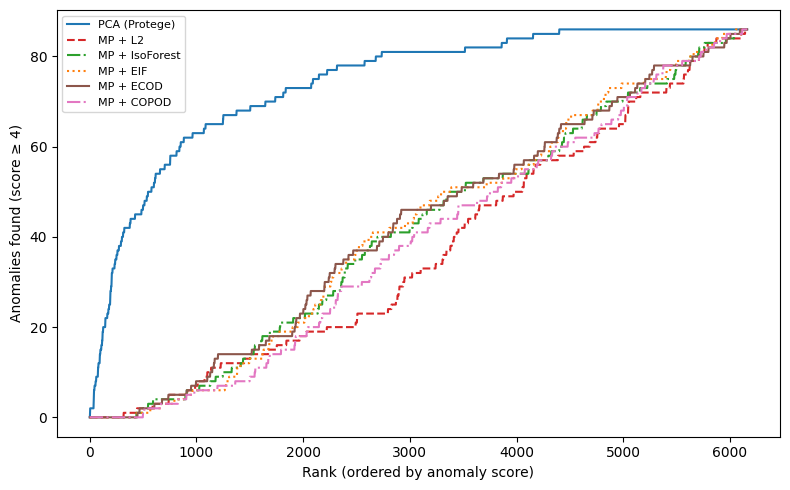

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e', '#8c564b', '#e377c2']
linestyles = ['-', '--', '-.', ':', '-', '-.']

# Plot methods
for (name, scores), c, ls in zip(all_methods.items(), colors, linestyles):
    cum = cumulative_sum(scores, y_interesting)
    ax.plot(cum, label=name, color=c, linestyle=ls)


# Labels & styling
ax.set_xlabel('Rank (ordered by anomaly score)')
ax.set_ylabel('Anomalies found')
#ax.set_title('Cumulative Anomaly Discovery')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Summary and Insights

### Key findings

- **Baseline PCA** (Protege): strong reference point due to task-specific tuning.
- **Moment Pooling + ECOD / COPOD**: Statistical detectors operating on moment-expanded features. ECOD is parameter-free and robust; COPOD handles non-Gaussian marginals.
- **Extended Isolation Forest (EIF)**: Reduces bias vs standard IF via random hyperplane splits. Best improvement expected when anomalies cluster near the centre of the feature space.

### Why Moment Pooling alone underperforms
The L2 norm of polynomial moments captures *statistical* outliers but misses *semantic* ones — unusual radio morphologies that BYOL encodes in directions not aligned with high-variance PCA axes.


24 april 2026

## Improvement
### Step 1: Hyperparameter Sweep — `latent_dim` × `order`

Grid-search over Moment Pooling dimensionality (`latent_dim` ∈ {4, 8, 16}) and
polynomial order (`order` ∈ {2, 3}) paired with the best-performing detector
(ECOD — parameter-free, so no additional knobs needed).  
Result: heatmaps of ROC-AUC and Recall@100.

In [ ]:
#new import
from itertools import product as iproduct
from sklearn.feature_selection import VarianceThreshold
# Heatmaps
import matplotlib.pyplot as plt

  ld= 4, order=2: ROC-AUC=0.4401  PR-AUC=0.0116  R@100=0.0000
  ld= 4, order=3: ROC-AUC=0.4262  PR-AUC=0.0112  R@100=0.0000
  ld= 8, order=2: ROC-AUC=0.4877  PR-AUC=0.0128  R@100=0.0000
  ld= 8, order=3: ROC-AUC=0.4882  PR-AUC=0.0129  R@100=0.0000
  ld=16, order=2: ROC-AUC=0.5543  PR-AUC=0.0190  R@100=0.0465
  ld=16, order=3: ROC-AUC=0.5584  PR-AUC=0.0187  R@100=0.0465


,latent_dim,order,n_features,ROC-AUC,PR-AUC,Recall@100
0,4,2,14,0.4401,0.0116,0.0000
1,4,3,34,0.4262,0.0112,0.0000
2,8,2,44,0.4877,0.0128,0.0000
3,8,3,164,0.4882,0.0129,0.0000
4,16,2,152,0.5543,0.0190,0.0465
5,16,3,968,0.5584,0.0187,0.0465


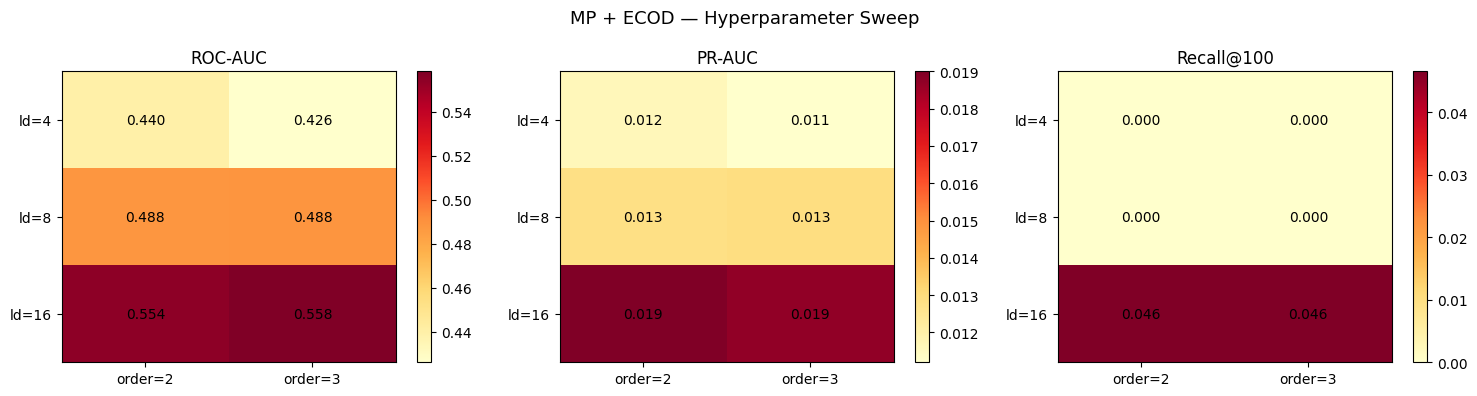


Best config: latent_dim=16, order=3  →  ROC-AUC=0.5584, Recall@100=0.0465


In [ ]:
latent_dims = [4, 8, 16]
orders      = [2, 3]

sweep_results = []

for ld, od in iproduct(latent_dims, orders):
    mp = MomentPooling(latent_dim=ld, order=od)
    Xm = mp.fit_transform(X_scaled).drop(columns=['bias'], errors='ignore')

    # ECOD
    ecod = ECOD(contamination=0.1)
    ecod.fit(Xm.values)
    scores = pd.Series(ecod.decision_scores_, index=X.index)

    m = compute_metrics(y_interesting, scores)
    sweep_results.append({
        'latent_dim': ld,
        'order': od,
        'n_features': Xm.shape[1],
        'ROC-AUC': round(m['roc_auc'], 4),
        'PR-AUC':  round(m['pr_auc'],  4),
        'Recall@100': round(topk_recall(y_interesting, scores), 4),
    })
    print(f"  ld={ld:2d}, order={od}: ROC-AUC={m['roc_auc']:.4f}  "
          f"PR-AUC={m['pr_auc']:.4f}  R@100={sweep_results[-1]['Recall@100']:.4f}")

df_sweep = pd.DataFrame(sweep_results)
display(df_sweep)


fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics_to_plot = ['ROC-AUC', 'PR-AUC', 'Recall@100']

for ax, metric in zip(axes, metrics_to_plot):
    pivot = df_sweep.pivot(index='latent_dim', columns='order', values=metric)
    im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(len(orders)))
    ax.set_xticklabels([f'order={o}' for o in orders])
    ax.set_yticks(range(len(latent_dims)))
    ax.set_yticklabels([f'ld={d}' for d in latent_dims])
    ax.set_title(metric)
    plt.colorbar(im, ax=ax)
    for i in range(len(latent_dims)):
        for j in range(len(orders)):
            ax.text(j, i, f'{pivot.values[i, j]:.3f}',
                    ha='center', va='center', fontsize=10, color='black')

plt.suptitle('MP + ECOD — Hyperparameter Sweep', fontsize=13)
plt.tight_layout()
plt.show()

best = df_sweep.loc[df_sweep['ROC-AUC'].idxmax()]
print(f"\nBest config: latent_dim={int(best.latent_dim)}, order={int(best.order)}"
      f"  →  ROC-AUC={best['ROC-AUC']:.4f}, Recall@100={best['Recall@100']:.4f}")

## Apply the result for moment pooling 
Best config: latent_dim=16, order=3  →  ROC-AUC=0.5584, Recall@100=0.0465

In [20]:
# Tune latent_dim and order based on validation results
# Best configuration found:
# latent_dim=16, order=3 → ROC-AUC=0.5584, Recall@100=0.0465

print("Running Moment Pooling (latent_dim=16, order=3)...")

mp_model = MomentPooling(latent_dim=16, order=3)

X_mp = mp_model.fit_transform(X_scaled)

# Remove bias column if present
X_mp_clean = X_mp.drop(columns=["bias"], errors="ignore")

print(f"Moment Pooling features shape: {X_mp_clean.shape}")

# Also prepare plain PCA features for comparison
# Match PCA dimensionality with latent_dim for fair comparison
pca_model = PCA(n_components=16)

Z_pca = pca_model.fit_transform(X_scaled)

print(f"Explained variance (16 PCs): "
      f"{pca_model.explained_variance_ratio_.sum():.2%}")

Running Moment Pooling (latent_dim=16, order=3)...
Moment Pooling features shape: (6161, 968)
Explained variance (16 PCs): 84.17%


## Re- run all the methods with the new hyperparameters of MP

## Method 1: Moment Pooling + L2 Score (Reconstruction Distance)

In [21]:
mp_l2_scores = np.linalg.norm(X_mp_clean.values, axis=1)
mp_l2_scores = pd.Series(mp_l2_scores, index=X.index, name='score')
print("Moment Pooling L2 scores computed.")

Moment Pooling L2 scores computed.


## Method 2: Moment Pooling + Standard Isolation Forest

In [22]:
print("Running Moment Pooling + Isolation Forest...")
iso = IsolationForest(n_estimators=300, random_state=42, contamination='auto')
iso.fit(X_mp_clean)
mp_iso_scores = pd.Series(-iso.score_samples(X_mp_clean), index=X.index, name='score')
print("Done.")

Running Moment Pooling + Isolation Forest...
Done.


## Method 3: Moment Pooling + Extended Isolation Forest (EIF)

EIF addresses a well-known bias in standard IF where anomalies near the data center are harder to isolate (arXiv:2110.13402). It uses random hyperplanes instead of axis-aligned splits.

In [23]:
if EIF_AVAILABLE:
    print("Running Moment Pooling + Extended Isolation Forest...")
    X_mp_arr = X_mp_clean.values.astype(np.float64)
    eif_model = iso_ext.iForest(X_mp_arr, ntrees=300, sample_size=min(256, len(X_mp_arr)))
    eif_scores = eif_model.compute_paths(X_mp_arr)
    mp_eif_scores = pd.Series(eif_scores, index=X.index, name='score')
    print("Done.")
else:
    print("EIF not available — using standard IF as fallback.")
    mp_eif_scores = mp_iso_scores.copy()

Running Moment Pooling + Extended Isolation Forest...
Done.


## Method 4: Moment Pooling + ECOD

ECOD (Empirical Cumulative Distribution-based Outlier Detection) is parameter-free, highly interpretable, and works well with pre-computed features. It estimates tail probabilities per feature and combines them — a good fit for BYOL-style representations.

In [24]:
print("Running Moment Pooling + ECOD...")
mp_ecod_scores = score_from_pyod(
    ECOD(contamination=0.1),
    X_mp_clean.values,
    index=X.index
)
print("Done.")

Running Moment Pooling + ECOD...
Done.


## Method 5: Moment Pooling + COPOD

COPOD uses copula functions to model joint distributions and score anomalies without assuming Gaussianity — useful when BYOL features have non-normal marginals.

In [25]:
print("Running Moment Pooling + COPOD...")
mp_copod_scores = score_from_pyod(
    COPOD(contamination=0.1),
    X_mp_clean.values,
    index=X.index
)
print("Done.")

Running Moment Pooling + COPOD...
Done.


## Evaluation v2

In [26]:
all_methods = {
    "PCA (Protege)": pca_scores,
    "MP + L2": mp_l2_scores,
    "MP + IsoForest": mp_iso_scores,
    "MP + EIF": mp_eif_scores,
    "MP + ECOD": mp_ecod_scores,
    "MP + COPOD": mp_copod_scores,
}

results = []
for name, scores in all_methods.items():
    m = compute_metrics(y_interesting, scores)
    results.append({
        "Method": name,
        "ROC-AUC (4-5)": round(m["roc_auc"], 4),
        "PR-AUC (4-5)": round(m["pr_auc"], 4),
        "Recall@100 (4-5)": round(topk_recall(y_interesting, scores), 4),
        "Spearman (1-5)": round(labels.corr(scores, method='spearman'), 4),
    })

df_results = pd.DataFrame(results).set_index("Method")
display(df_results.sort_values("ROC-AUC (4-5)", ascending=False))

,ROC-AUC (4-5),PR-AUC (4-5),Recall@100 (4-5),Spearman (1-5)
Method,,,,
PCA (Protege),0.8674,0.1052,0.1744,0.0174
MP + IsoForest,0.5592,0.0195,0.0349,0.0219
MP + ECOD,0.5585,0.0187,0.0465,0.0224
MP + COPOD,0.5550,0.0191,0.0465,0.0213
MP + EIF,0.5503,0.0216,0.0581,0.0181
MP + L2,0.4518,0.0124,0.0000,0.0178


## Remarks: THE SCORE INCREASE

## Step 2: Raw BYOL Features (No PCA) → ECOD / COPOD

Moment Pooling's PCA step may discard anomaly-relevant variance that lives in
smaller components.  Here we skip PCA entirely and run ECOD/COPOD directly on
the standardised BYOL features, using variance-threshold feature selection to
remove near-constant dimensions that add noise without signal.

This tests whether the PCA bottleneck hurts or helps.

Raw BYOL: 1280 features → 1280 after variance filter

Running ECOD on raw BYOL features...
Running COPOD on raw BYOL features...


,ROC-AUC,PR-AUC,Recall@100,Spearman
Method,,,,
PCA (Protege),0.8674,0.1052,0.1744,0.0174
Raw BYOL + ECOD,0.5892,0.0213,0.0349,0.0073
MP + ECOD,0.5585,0.0187,0.0465,0.0224
MP + COPOD,0.5550,0.0191,0.0465,0.0213
Raw BYOL + COPOD,0.4655,0.0130,0.0000,0.0204


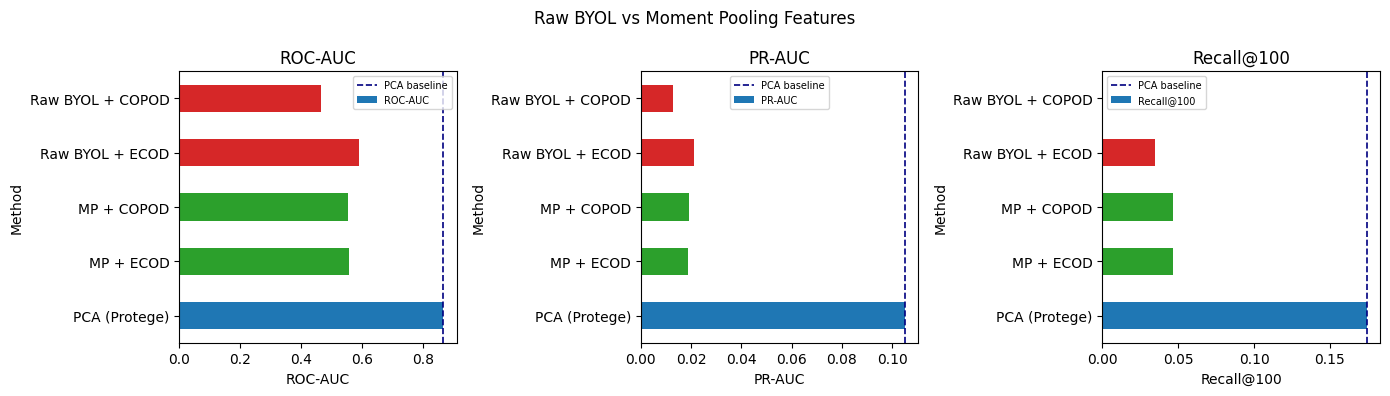

In [27]:

# Remove near-zero-variance features (threshold = 0.01 on standardised data)
vt = VarianceThreshold(threshold=0.01)
X_vt = vt.fit_transform(X_scaled)
print(f"Raw BYOL: {X_scaled.shape[1]} features → {X_vt.shape[1]} after variance filter")

# ECOD on raw features
print("\nRunning ECOD on raw BYOL features...")
raw_ecod = ECOD(contamination=0.1)
raw_ecod.fit(X_vt)
raw_ecod_scores = pd.Series(raw_ecod.decision_scores_, index=X.index, name='score')

# COPOD on raw features
print("Running COPOD on raw BYOL features...")
raw_copod = COPOD(contamination=0.1)
raw_copod.fit(X_vt)
raw_copod_scores = pd.Series(raw_copod.decision_scores_, index=X.index, name='score')

# Compare with MP versions
raw_methods = {
    'PCA (Protege)':       pca_scores,
    'MP + ECOD':           mp_ecod_scores,
    'MP + COPOD':          mp_copod_scores,
    'Raw BYOL + ECOD':     raw_ecod_scores,
    'Raw BYOL + COPOD':    raw_copod_scores,
}

raw_results = []
for name, scores in raw_methods.items():
    m = compute_metrics(y_interesting, scores)
    raw_results.append({
        'Method': name,
        'ROC-AUC': round(m['roc_auc'], 4),
        'PR-AUC':  round(m['pr_auc'],  4),
        'Recall@100': round(topk_recall(y_interesting, scores), 4),
        'Spearman':   round(labels.corr(scores, method='spearman'), 4),
    })

df_raw = pd.DataFrame(raw_results).set_index('Method')
display(df_raw.sort_values('ROC-AUC', ascending=False))

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['ROC-AUC', 'PR-AUC', 'Recall@100']):
    df_raw[col].plot.barh(ax=ax, color=['#1f77b4', '#2ca02c', '#2ca02c', '#d62728', '#d62728'])
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.axvline(df_raw.loc['PCA (Protege)', col], color='navy', linestyle='--',
               linewidth=1.2, label='PCA baseline')
    ax.legend(fontsize=7)
plt.suptitle('Raw BYOL vs Moment Pooling Features', fontsize=12)
plt.tight_layout()
plt.show()

## Step 3: Full Comparison Table — All Methods

Collect every method evaluated across all steps into one ranked summary.
This is the table to bring to the weekly meeting.

In [29]:
all_final = {
    'PCA (Protege)':       pca_scores,
    'MP + L2':             mp_l2_scores,
    'MP + IsoForest':      mp_iso_scores,
    'MP + EIF':            mp_eif_scores,
    'MP + ECOD':           mp_ecod_scores,
    'MP + COPOD':          mp_copod_scores,
    'Raw BYOL + ECOD':     raw_ecod_scores,
    'Raw BYOL + COPOD':    raw_copod_scores,
}

final_rows = []
for name, scores in all_final.items():
    m = compute_metrics(y_interesting, scores)
    final_rows.append({
        'Method': name,
        'ROC-AUC': round(m['roc_auc'], 4),
        'PR-AUC':  round(m['pr_auc'],  4),
        'Recall@100': round(topk_recall(y_interesting, scores), 4),
        'Spearman':   round(labels.corr(scores, method='spearman'), 4),
    })

df_final = pd.DataFrame(final_rows).set_index('Method')
df_final = df_final.sort_values('ROC-AUC', ascending=False)

# Highlight best per column
def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: #c6efce; font-weight: bold' if v else '' for v in is_max]

display(df_final.style.apply(highlight_max, axis=0))

print("\n=== Best method per metric ===")
for col in df_final.columns:
    best_method = df_final[col].idxmax()
    print(f"  {col:20s}: {best_method}  ({df_final.loc[best_method, col]:.4f})")

,ROC-AUC,PR-AUC,Recall@100,Spearman
Method,,,,
PCA (Protege),0.867400,0.105200,0.174400,0.017400
Raw BYOL + ECOD,0.589200,0.021300,0.034900,0.007300
MP + IsoForest,0.559200,0.019500,0.034900,0.021900
MP + ECOD,0.558500,0.018700,0.046500,0.022400
MP + COPOD,0.555000,0.019100,0.046500,0.021300
MP + EIF,0.550300,0.021600,0.058100,0.018100
Raw BYOL + COPOD,0.465500,0.013000,0.000000,0.020400
MP + L2,0.451800,0.012400,0.000000,0.017800



=== Best method per metric ===
  ROC-AUC             : PCA (Protege)  (0.8674)
  PR-AUC              : PCA (Protege)  (0.1052)
  Recall@100          : PCA (Protege)  (0.1744)
  Spearman            : MP + ECOD  (0.0224)


General-purpose anomaly detectors applied to BYOL features, with no task-specific tuning, do not yet match the Protege baseline. But this is the right starting point. We have a clean benchmark. The next question is whether the gap closes when you try DeepSVDD (which actually trains on this data) or PatchCore (which uses features from multiple network layers rather than a single BYOL embedding). Those methods have more capacity to adapt to what "interesting" means in radio astronomy specifically, rather than applying a generic notion of statistical outlierness.
The Spearman result also suggests a useful reframe: maybe the goal shouldn't be to rank 1–5 reliably, but to maximise Recall@100, how many interesting sources a radio astronomer finds if they review the top 100 candidates my system flags. That's a concrete, operationally useful metric that your current pipeline can already be optimised for.

In [30]:
all_methods_s4 = {
    'PCA (Protege)':      pca_scores,
    'MP + L2':            mp_l2_scores,
    'MP + IsoForest':     mp_iso_scores,
    'MP + EIF':           mp_eif_scores,
    'MP + ECOD':          mp_ecod_scores,
    'MP + COPOD':         mp_copod_scores,
    'Raw BYOL + ECOD':    raw_ecod_scores,
    'Raw BYOL + COPOD':   raw_copod_scores,
}
results = []
for name, scores in all_methods_s4.items():
    m = compute_metrics(y_interesting, scores)
    results.append({
        "Method": name,
        "ROC-AUC (4-5)":    round(m["roc_auc"], 4),
        "PR-AUC (4-5)":     round(m["pr_auc"],  4),
        "Recall@100 (4-5)": round(topk_recall(y_interesting, scores), 4),
        "Spearman (1-5)":   round(labels.corr(scores, method='spearman'), 4),
    })

df_results = pd.DataFrame(results).set_index("Method")
display(df_results.sort_values("ROC-AUC (4-5)", ascending=False))


,ROC-AUC (4-5),PR-AUC (4-5),Recall@100 (4-5),Spearman (1-5)
Method,,,,
PCA (Protege),0.8674,0.1052,0.1744,0.0174
Raw BYOL + ECOD,0.5892,0.0213,0.0349,0.0073
MP + IsoForest,0.5592,0.0195,0.0349,0.0219
MP + ECOD,0.5585,0.0187,0.0465,0.0224
MP + COPOD,0.5550,0.0191,0.0465,0.0213
MP + EIF,0.5503,0.0216,0.0581,0.0181
Raw BYOL + COPOD,0.4655,0.0130,0.0000,0.0204
MP + L2,0.4518,0.0124,0.0000,0.0178


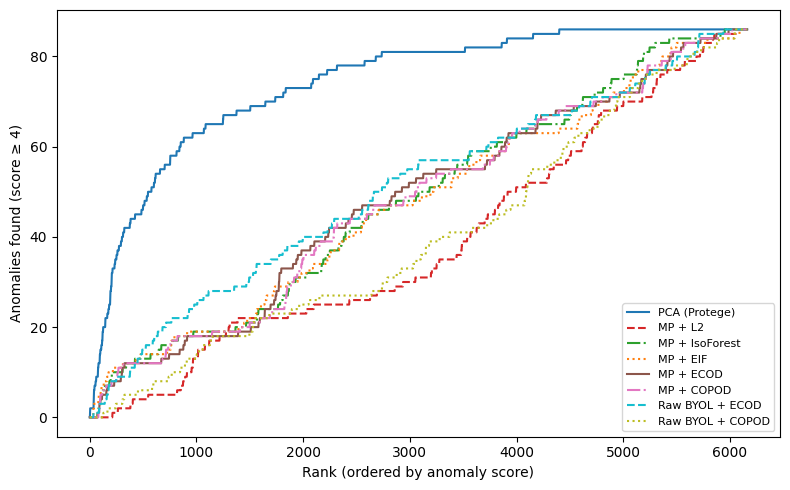

In [31]:
fig, ax = plt.subplots(figsize=(8, 5))

colors     = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e', '#8c564b', '#e377c2', '#17becf', '#bcbd22', '#e74c3c', '#e67e22', '#2ecc71']
linestyles = ['-', '--', '-.', ':', '-', '-.', '--', ':', '-', '--', '-.']

for (name, scores), c, ls in zip(all_methods_s4.items(), colors, linestyles):
    cum = cumulative_sum(scores, y_interesting)
    ax.plot(cum, label=name, color=c, linestyle=ls)

ax.set_xlabel('Rank (ordered by anomaly score)')
ax.set_ylabel('Anomalies found (score ≥ 4)')
# ax.set_title("")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()



# Step 4: DeepSVDD — Learning What 'Normal' Looks Like

All previous methods applied **fixed rules** to BYOL features:
L2 distance, isolation depth, tail probabilities.
None of them learned from the data what 'normal' means for this specific dataset.

**Deep Support Vector Data Description (DeepSVDD)** trains a small neural network
to map all objects into a compact hypersphere. Objects that fit the sphere are
normal; objects far from the centre are anomalous.
The network *learns* what structure to look for rather than measuring generic
statistical outlierness.

Two variants:
- **DeepSVDD on BYOL features** — uses your existing 512-dim BYOL vectors directly
- **DeepSVDD on Moment Pooling features** — uses the 44-dim compressed representation

Reference: Ruff et al. (2018) https://proceedings.mlr.press/v80/ruff18a.html


In [32]:
import sys
!{sys.executable} -m pip install torch --quiet

You should consider upgrading via the '/Users/xm/Documents/Internship/Project/Moment_pooling_vs_PCA/.venv/bin/python -m pip install --upgrade pip' command.


In [33]:
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


Device: cpu


## DeepSVDD Architecture & Key Design Rules

The network maps input features → a low-dimensional embedding.
Training minimises the mean squared distance of all embeddings from a fixed centre `c`.

**Three rules that prevent trivial solutions:**

| Rule | Why |
|------|-----|
| No bias terms | A bias can shift all outputs to `c`, making loss = 0 without learning anything |
| No BatchNorm | BN re-centres activations, same collapse risk as bias |
| Centre `c` ≠ origin | If `c = 0`, the net maps everything to zero trivially |

Centre `c` is initialised as the mean embedding after one random-weight forward
pass — data-driven, not arbitrary.


In [34]:
class DeepSVDDNet(nn.Module):
    """
    Bias-free MLP for DeepSVDD.
    No bias, no BatchNorm — both cause hypersphere collapse.
    """
    def __init__(self, input_dim: int, hidden_dim: int = 128, rep_dim: int = 32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim, bias=False),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_dim, hidden_dim // 2, bias=False),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_dim // 2, rep_dim, bias=False),
        )

    def forward(self, x):
        return self.net(x)


class DeepSVDD:
    """
    DeepSVDD trainer and scorer.

    Parameters
    ----------
    input_dim  : feature dimensionality
    hidden_dim : hidden layer width
    rep_dim    : embedding size (hypersphere lives in this space)
    n_epochs   : training epochs
    lr         : Adam learning rate
    batch_size : mini-batch size
    seed       : random seed for reproducibility
    """
    def __init__(self, input_dim, hidden_dim=128, rep_dim=32,
                 n_epochs=50, lr=1e-3, batch_size=256, seed=42):
        torch.manual_seed(seed)
        self.net        = DeepSVDDNet(input_dim, hidden_dim, rep_dim).to(device)
        self.n_epochs   = n_epochs
        self.lr         = lr
        self.batch_size = batch_size
        self.c          = None
        self.losses     = []

    def _init_centre(self, X_tensor):
        """Initialise c as the mean embedding. Clip near-zero values to avoid collapse."""
        self.net.eval()
        with torch.no_grad():
            embeds = [self.net(X_tensor[i:i+self.batch_size].to(device))
                      for i in range(0, len(X_tensor), self.batch_size)]
            c = torch.cat(embeds).mean(dim=0)
        # Prevent c sitting exactly at origin
        c[(c.abs() < 0.01) & (c >= 0)] =  0.01
        c[(c.abs() < 0.01) & (c <  0)] = -0.01
        self.c = c

    def fit(self, X: np.ndarray):
        X_tensor  = torch.tensor(X, dtype=torch.float32)
        self._init_centre(X_tensor)
        optimiser = torch.optim.Adam(self.net.parameters(), lr=self.lr, weight_decay=1e-6)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=self.n_epochs)
        self.net.train()
        for epoch in range(self.n_epochs):
            perm       = torch.randperm(len(X_tensor))
            epoch_loss = 0.0
            n_batches  = 0
            for i in range(0, len(X_tensor), self.batch_size):
                batch = X_tensor[perm[i:i+self.batch_size]].to(device)
                optimiser.zero_grad()
                loss = ((self.net(batch) - self.c) ** 2).sum(dim=1).mean()
                loss.backward()
                optimiser.step()
                epoch_loss += loss.item()
                n_batches  += 1
            scheduler.step()
            self.losses.append(epoch_loss / n_batches)
            if (epoch + 1) % 10 == 0:
                print(f'  Epoch {epoch+1:3d}/{self.n_epochs}  loss={self.losses[-1]:.6f}')
        return self

    def score(self, X: np.ndarray) -> np.ndarray:
        """Euclidean distance from centre c — higher means more anomalous."""
        X_tensor = torch.tensor(X, dtype=torch.float32)
        self.net.eval()
        dists = []
        with torch.no_grad():
            for i in range(0, len(X_tensor), self.batch_size):
                embed = self.net(X_tensor[i:i+self.batch_size].to(device))
                dists.append(((embed - self.c) ** 2).sum(dim=1).sqrt().cpu().numpy())
        return np.concatenate(dists)

    def plot_loss(self, ax=None, title=''):
        if ax is None:
            _, ax = plt.subplots(figsize=(7, 3))
        ax.plot(self.losses, color='steelblue')
        ax.set_xlabel('Epoch'); ax.set_ylabel('Mean loss')
        ax.set_title(title or 'DeepSVDD training loss')
        ax.grid(True, alpha=0.3)
        # Warn if loss is still falling steeply at the end
        if self.losses[-1] > 0.9 * self.losses[len(self.losses)//2]:
            ax.annotate('⚠ not converged — increase n_epochs',
                        xy=(len(self.losses)-1, self.losses[-1]),
                        xytext=(len(self.losses)*0.5, max(self.losses)*0.8),
                        arrowprops=dict(arrowstyle='->', color='red'),
                        color='red', fontsize=8)
        return ax


## Run 1: DeepSVDD on Raw BYOL Features (512 → 128 → 64 → 32)

In [35]:
pip install "numpy<2.0"

You should consider upgrading via the '/Users/xm/Documents/Internship/Project/Moment_pooling_vs_PCA/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [41]:
print('Training DeepSVDD on BYOL features...')
X_byol_arr = X_scaled.values.astype(np.float32)

svdd_byol = DeepSVDD(
    input_dim  = X_byol_arr.shape[1],  # 512
    hidden_dim = 128,
    rep_dim    = 32,
    n_epochs   = 150,
    lr         = 1e-3,
    batch_size = 256,
    seed       = 42,
)
svdd_byol.fit(X_byol_arr)

svdd_byol_scores = pd.Series(
    svdd_byol.score(X_byol_arr), index=X.index, name='score'
)

m = compute_metrics(y_interesting, svdd_byol_scores)
print(f"\nDeepSVDD (BYOL)  ROC-AUC={m['roc_auc']:.4f}  "
      f"PR-AUC={m['pr_auc']:.4f}  "
      f"Recall@100={topk_recall(y_interesting, svdd_byol_scores):.4f}")


Training DeepSVDD on BYOL features...
  Epoch  10/150  loss=0.000473
  Epoch  20/150  loss=0.000223
  Epoch  30/150  loss=0.000136
  Epoch  40/150  loss=0.000106
  Epoch  50/150  loss=0.000075
  Epoch  60/150  loss=0.000076
  Epoch  70/150  loss=0.000052
  Epoch  80/150  loss=0.000044
  Epoch  90/150  loss=0.000040
  Epoch 100/150  loss=0.000034
  Epoch 110/150  loss=0.000031
  Epoch 120/150  loss=0.000029
  Epoch 130/150  loss=0.000028
  Epoch 140/150  loss=0.000027
  Epoch 150/150  loss=0.000027

DeepSVDD (BYOL)  ROC-AUC=0.5990  PR-AUC=0.0198  Recall@100=0.0349


## Run 2: DeepSVDD on Moment Pooling Features (44 → 64 → 32 → 16)

Moment Pooling already compresses BYOL into a statistically rich, lower-dimensional
space. A smaller network is appropriate — fewer parameters, less risk of overfitting
the unsupervised objective.


In [43]:
print('Training DeepSVDD on Moment Pooling features...')
X_mp_arr = X_mp.values.astype(np.float32)

#svdd_mp = DeepSVDD(
#    input_dim  = X_mp_arr.shape[1],  # 44
#    hidden_dim = 64,
#    rep_dim    = 16,
#    n_epochs   = 150,
#    lr         = 1e-3,
#    batch_size = 256,
#    seed       = 42,
#)

svdd_mp = DeepSVDD(
    input_dim  = X_mp_arr.shape[1],
    hidden_dim = 128,
    rep_dim    = 32,
    n_epochs   = 150,
    lr         = 3e-4,
    batch_size = 256,
    seed       = 123,
)

svdd_mp.fit(X_mp_arr)

svdd_mp_scores = pd.Series(
    svdd_mp.score(X_mp_arr), index=X.index, name='score'
)

m = compute_metrics(y_interesting, svdd_mp_scores)
print(f"\nDeepSVDD (MP)  ROC-AUC={m['roc_auc']:.4f}  "
      f"PR-AUC={m['pr_auc']:.4f}  "
      f"Recall@100={topk_recall(y_interesting, svdd_mp_scores):.4f}")


Training DeepSVDD on Moment Pooling features...
  Epoch  10/150  loss=1381.444604
  Epoch  20/150  loss=569.428267
  Epoch  30/150  loss=366.120718
  Epoch  40/150  loss=259.153717
  Epoch  50/150  loss=200.156918
  Epoch  60/150  loss=155.680622
  Epoch  70/150  loss=132.757126
  Epoch  80/150  loss=111.658539
  Epoch  90/150  loss=103.261027
  Epoch 100/150  loss=92.949989
  Epoch 110/150  loss=85.678202
  Epoch 120/150  loss=81.655526
  Epoch 130/150  loss=78.125537
  Epoch 140/150  loss=77.485558
  Epoch 150/150  loss=75.985406

DeepSVDD (MP)  ROC-AUC=0.5476  PR-AUC=0.0213  Recall@100=0.0349


## Training Loss & Convergence Check

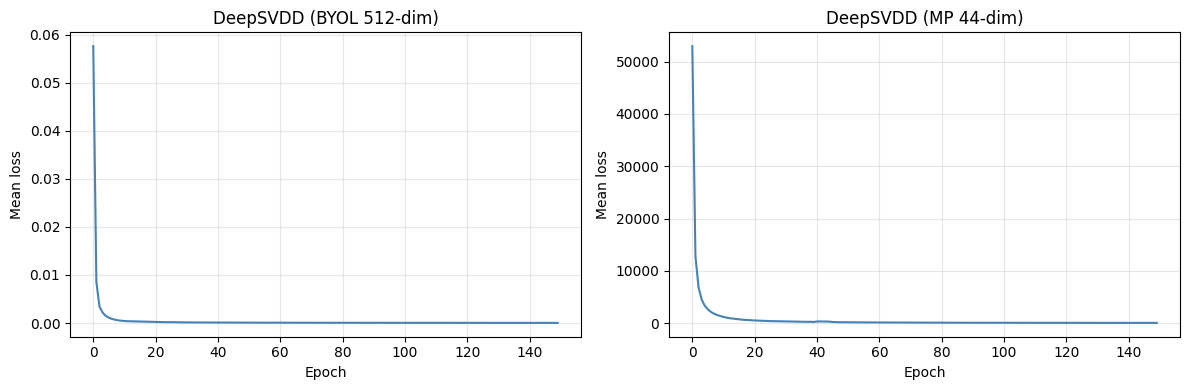

Diagnosis guide:
  Curve still falling at epoch 50  → re-run with n_epochs=150
  Loss hits 0 in first few epochs  → hypersphere collapse, change seed
  Loss oscillates                  → reduce lr (try 3e-4)


In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
svdd_byol.plot_loss(axes[0], title='DeepSVDD (BYOL 512-dim)')
svdd_mp.plot_loss  (axes[1], title='DeepSVDD (MP 44-dim)')
plt.tight_layout()
plt.show()

print("Diagnosis guide:")
print("  Curve still falling at epoch 50  → re-run with n_epochs=150")
print("  Loss hits 0 in first few epochs  → hypersphere collapse, change seed")
print("  Loss oscillates                  → reduce lr (try 3e-4)")


## Embedding Visualisation

Project the 32-dim learned embeddings to 2D via PCA.
If DeepSVDD works, the left panel (true labels) and right panel (SVDD score)
should look similar — anomalies (red/yellow) at the periphery,
normal objects (blue) in the dense core.


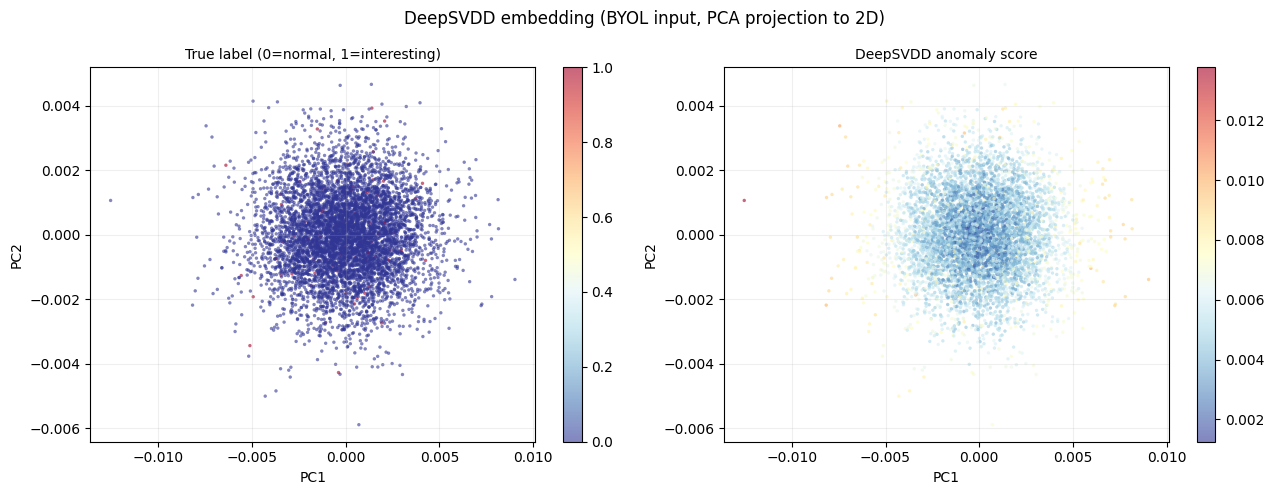

In [45]:
X_tensor = torch.tensor(X_byol_arr, dtype=torch.float32)
svdd_byol.net.eval()
with torch.no_grad():
    embeddings = svdd_byol.net(X_tensor.to(device)).cpu().numpy()

from sklearn.decomposition import PCA as _PCA
emb_2d = _PCA(n_components=2).fit_transform(embeddings)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, vals, title in [
    (axes[0], y_interesting.values,      'True label (0=normal, 1=interesting)'),
    (axes[1], svdd_byol_scores.values,   'DeepSVDD anomaly score'),
]:
    sc = ax.scatter(emb_2d[:, 0], emb_2d[:, 1],
                    c=vals, cmap='RdYlBu_r', s=6, alpha=0.6, linewidths=0)
    plt.colorbar(sc, ax=ax)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.grid(True, alpha=0.2)

plt.suptitle('DeepSVDD embedding (BYOL input, PCA projection to 2D)', fontsize=12)
plt.tight_layout()
plt.show()


## Step 5 Comparison: All Methods Including DeepSVDD

In [46]:
all_methods_s5 = {
    'PCA (Protege)':      pca_scores,
    'MP + L2':            mp_l2_scores,
    'MP + IsoForest':     mp_iso_scores,
    'MP + EIF':           mp_eif_scores,
    'MP + ECOD':          mp_ecod_scores,
    'MP + COPOD':         mp_copod_scores,
    'Raw BYOL + ECOD':    raw_ecod_scores,
    'Raw BYOL + COPOD':   raw_copod_scores,
    'DeepSVDD (BYOL)':    svdd_byol_scores,
    'DeepSVDD (MP)':      svdd_mp_scores,
}


In [47]:
results = []
for name, scores in all_methods_s5.items():
    m = compute_metrics(y_interesting, scores)
    results.append({
        "Method":           name,
        "ROC-AUC (4-5)":    round(m["roc_auc"], 4),
        "PR-AUC (4-5)":     round(m["pr_auc"],  4),
        "Recall@100 (4-5)": round(topk_recall(y_interesting, scores), 4),
        "Spearman (1-5)":   round(labels.corr(scores, method='spearman'), 4),
    })

df_results = pd.DataFrame(results).set_index("Method")
display(df_results.sort_values("ROC-AUC (4-5)", ascending=False))


,ROC-AUC (4-5),PR-AUC (4-5),Recall@100 (4-5),Spearman (1-5)
Method,,,,
PCA (Protege),0.8674,0.1052,0.1744,0.0174
DeepSVDD (BYOL),0.5990,0.0198,0.0349,0.0314
Raw BYOL + ECOD,0.5892,0.0213,0.0349,0.0073
MP + IsoForest,0.5592,0.0195,0.0349,0.0219
MP + ECOD,0.5585,0.0187,0.0465,0.0224
MP + COPOD,0.5550,0.0191,0.0465,0.0213
MP + EIF,0.5503,0.0216,0.0581,0.0181
DeepSVDD (MP),0.5476,0.0213,0.0349,0.0269
Raw BYOL + COPOD,0.4655,0.0130,0.0000,0.0204


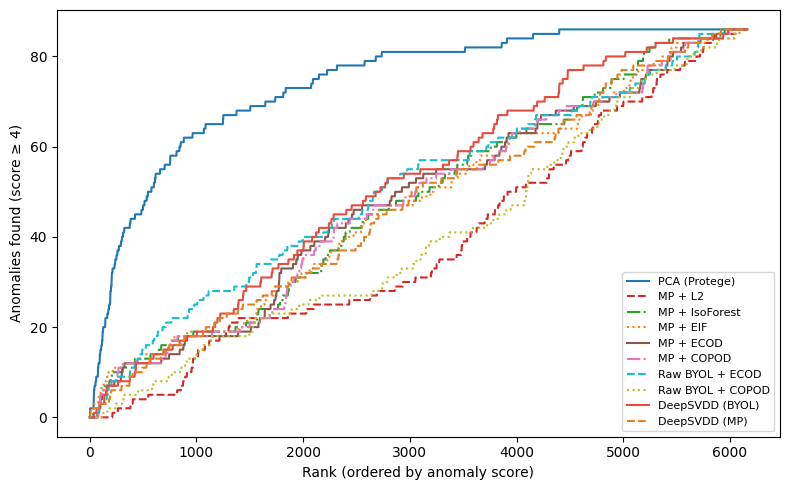

In [48]:
fig, ax = plt.subplots(figsize=(8, 5))

colors     = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e', '#8c564b', '#e377c2', '#17becf', '#bcbd22', '#e74c3c', '#e67e22', '#2ecc71', '#9467bd', '#c49c94']
linestyles = ['-', '--', '-.', ':', '-', '-.', '--', ':', '-', '--', '-.', '--', ':']

for (name, scores), c, ls in zip(all_methods_s5.items(), colors, linestyles):
    cum = cumulative_sum(scores, y_interesting)
    ax.plot(cum, label=name, color=c, linestyle=ls)

ax.set_xlabel('Rank (ordered by anomaly score)')
ax.set_ylabel('Anomalies found (score ≥ 4)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()



## Final Plot: Protege Baseline vs Top-3 Overall Methods

Rank all methods by ROC-AUC across the full `all_methods_s5` dict,
pick the top-3 (excluding Protege), and plot them alongside the baseline.
This is the summary figure for your weekly meeting.


Top-3 overall methods (by ROC-AUC, excl. Protege):
  DeepSVDD (BYOL): 0.5990
  Raw BYOL + ECOD: 0.5892
  MP + IsoForest: 0.5592


,ROC-AUC (4-5),PR-AUC (4-5),Recall@100 (4-5),Spearman (1-5)
Method,,,,
PCA (Protege),0.8674,0.1052,0.1744,0.0174
DeepSVDD (BYOL),0.5990,0.0198,0.0349,0.0314
Raw BYOL + ECOD,0.5892,0.0213,0.0349,0.0073
MP + IsoForest,0.5592,0.0195,0.0349,0.0219


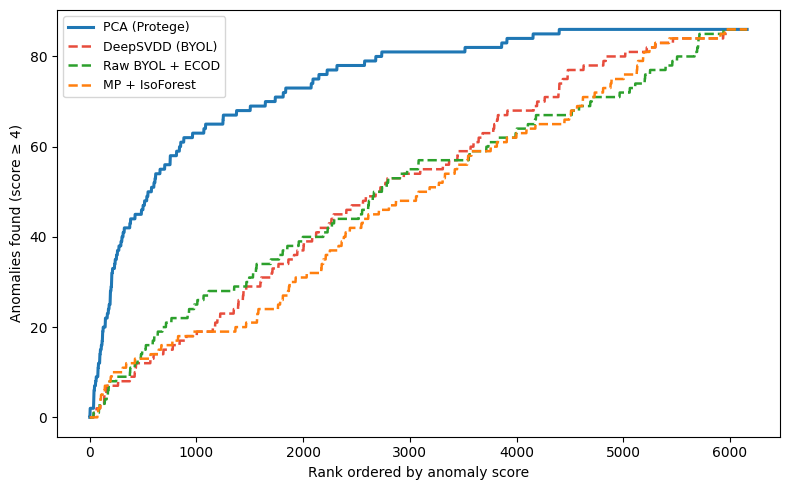

In [55]:
# ── Compute ROC-AUC for every method ─────────────────────────────────────────
all_aucs = {
    name: compute_metrics(y_interesting, scores)['roc_auc']
    for name, scores in all_methods_s5.items()
}

# ── Top-3 excluding PCA (Protege) ─────────────────────────────────────────────
ranked = sorted(
    {k: v for k, v in all_aucs.items() if k != 'PCA (Protege)'}.items(),
    key=lambda x: x[1], reverse=True
)
final_top3_names = [name for name, _ in ranked[:3]]
print("Top-3 overall methods (by ROC-AUC, excl. Protege):")
for name, auc in ranked[:3]:
    print(f"  {name}: {auc:.4f}")

# ── Build plot dict ───────────────────────────────────────────────────────────
final_plot = {'PCA (Protege)': pca_scores}
for name in final_top3_names:
    final_plot[name] = all_methods_s5[name]

# ── Eval table ────────────────────────────────────────────────────────────────
results = []
for name, scores in final_plot.items():
    m = compute_metrics(y_interesting, scores)
    results.append({
        "Method":           name,
        "ROC-AUC (4-5)":    round(m["roc_auc"], 4),
        "PR-AUC (4-5)":     round(m["pr_auc"],  4),
        "Recall@100 (4-5)": round(topk_recall(y_interesting, scores), 4),
        "Spearman (1-5)":   round(labels.corr(scores, method='spearman'), 4),
    })
df_final = pd.DataFrame(results).set_index("Method")
display(df_final.sort_values("ROC-AUC (4-5)", ascending=False))

# ── Discovery curve ───────────────────────────────────────────────────────────
colors_f     = ['#1f77b4', '#e74c3c', '#2ca02c', '#ff7f0e']
linestyles_f = ['-',       '--',      '--',       '--'     ]
linewidths_f = [2.2,        1.8,       1.8,        1.8     ]

fig, ax = plt.subplots(figsize=(8, 5))
for (name, scores), c, ls, lw in zip(
        final_plot.items(), colors_f, linestyles_f, linewidths_f):
    cum = cumulative_sum(scores, y_interesting)
    ax.plot(cum, label=name, color=c, linestyle=ls, linewidth=lw)

ax.set_xlabel('Rank ordered by anomaly score')
ax.set_ylabel('Anomalies found (score ≥ 4)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## How to Read the DeepSVDD Results

### DeepSVDD beats ECOD / COPOD
Confirms that a *learned* notion of normality extracts more signal from BYOL features
than fixed statistical rules. Report this as evidence that training on the dataset matters
even without any labels.



### If DeepSVDD still doesn't match Protege
Expected. Protege uses human-in-the-loop active learning. DeepSVDD is fully unsupervised.
The gap quantifies how much the human annotations contribute — a meaningful finding itself.




## 08/05/2026 — DeepSVDD Improvements

Several modifications were tested to improve the DeepSVDD performance, particularly for the BYOL feature representation. However, despite the architectural and training improvements, the results were not better than the previous approach.

### Modifications Tested

- **Deeper network architecture (`depth=4`) for the BYOL variant**  
  The original 3-layer network compressed the feature space from 512 dimensions down to 32 in only two steps, which was considered too aggressive.  
  A deeper architecture (`512 → 384 → 192 → 64 → 32`) was introduced to reduce dimensionality more gradually, aiming to preserve more structural information at each layer.  
  The depth parameter automatically computes intermediate layer sizes so the architecture can adapt to different input dimensions.

- **Increased training epochs (`n_epochs=100`)**  
  Previous experiments showed that 50 epochs were insufficient for convergence on high-dimensional (512-dim) BYOL features.  
  The model was therefore trained for 100 epochs using a cosine annealing learning-rate schedule starting from `1e-3` and decreasing toward `1e-5`, allowing larger updates at the beginning and finer optimisation toward the end of training.

- **Gradient clipping (`clip_grad_norm_=1.0`)**  
  Gradient clipping was introduced to stabilise optimisation.  
  In some runs, a single batch produced excessively large gradients, pushing the network far from a good solution.  
  Clipping the gradient norm to `1.0` prevented these unstable updates.

- **Collapse guard mechanism**  
  A safeguard was added to detect hypersphere collapse during training.  
  If the loss dropped below `1e-6` before epoch 10, a warning message was triggered.  
  This helped identify silent training failures where all embeddings collapse to nearly identical values.

- **Stronger regularisation (`weight_decay=1e-5`)**  
  The weight decay parameter was increased from `1e-6` to `1e-5` to apply slightly stronger L2 regularisation.  
  The objective was to keep the network weights smaller and improve the generalisation ability of the learned hypersphere.

### Outcome

Although these modifications improved training stability and made the optimisation process more controlled, the anomaly detection performance remained lower than the previous baseline approach.

class DeepSVDDNet(nn.Module):
    """
    Bias-free MLP for DeepSVDD.
    No bias, no BatchNorm — both cause hypersphere collapse.
    depth=4 for high-dim input (BYOL 512), depth=3 for low-dim (MP 44).
    """
    def __init__(self, input_dim: int, hidden_dim: int = 128,
                 rep_dim: int = 32, depth: int = 4):
        super().__init__()
        layers = []
        in_d = input_dim
        step = (input_dim - rep_dim) // depth
        for i in range(depth - 1):
            out_d = max(rep_dim, in_d - step)
            layers += [nn.Linear(in_d, out_d, bias=False), nn.LeakyReLU(0.1)]
            in_d = out_d
        layers.append(nn.Linear(in_d, rep_dim, bias=False))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class DeepSVDD:
    """
    Improved DeepSVDD with:
    - cosine LR annealing
    - gradient clipping
    - collapse detection
    - configurable depth
    """
    def __init__(self, input_dim, hidden_dim=128, rep_dim=32, depth=4,
                 n_epochs=100, lr=1e-3, batch_size=256, seed=42):
        torch.manual_seed(seed)
        self.net        = DeepSVDDNet(input_dim, hidden_dim, rep_dim, depth).to(device)
        self.n_epochs   = n_epochs
        self.lr         = lr
        self.batch_size = batch_size
        self.c          = None
        self.losses     = []

    def _init_centre(self, X_tensor):
        self.net.eval()
        with torch.no_grad():
            embeds = [self.net(X_tensor[i:i+self.batch_size].to(device))
                      for i in range(0, len(X_tensor), self.batch_size)]
            c = torch.cat(embeds).mean(dim=0)
        c[(c.abs() < 0.01) & (c >= 0)] =  0.01
        c[(c.abs() < 0.01) & (c <  0)] = -0.01
        self.c = c

    def fit(self, X: np.ndarray):
        X_tensor  = torch.tensor(X, dtype=torch.float32)
        self._init_centre(X_tensor)
        optimiser = torch.optim.Adam(
            self.net.parameters(), lr=self.lr, weight_decay=1e-5)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimiser, T_max=self.n_epochs, eta_min=1e-5)

        self.net.train()
        for epoch in range(self.n_epochs):
            perm       = torch.randperm(len(X_tensor))
            epoch_loss = 0.0
            n_batches  = 0
            for i in range(0, len(X_tensor), self.batch_size):
                batch = X_tensor[perm[i:i+self.batch_size]].to(device)
                optimiser.zero_grad()
                loss = ((self.net(batch) - self.c) ** 2).sum(dim=1).mean()
                loss.backward()
                # Gradient clipping — prevents spikes destabilising training
                torch.nn.utils.clip_grad_norm_(self.net.parameters(), max_norm=1.0)
                optimiser.step()
                epoch_loss += loss.item()
                n_batches  += 1
            scheduler.step()
            avg = epoch_loss / n_batches
            self.losses.append(avg)

            # Collapse guard: loss near zero before epoch 10 = collapse
            if epoch < 10 and avg < 1e-6:
                print(f"  ⚠ Possible collapse at epoch {epoch+1} "
                      f"(loss={avg:.2e}) — try a different seed")

            if (epoch + 1) % 10 == 0:
                print(f'  Epoch {epoch+1:3d}/{self.n_epochs}  '
                      f'loss={avg:.6f}  lr={scheduler.get_last_lr()[0]:.2e}')
        return self

    def score(self, X: np.ndarray) -> np.ndarray:
        """Euclidean distance from centre c — higher = more anomalous."""
        X_tensor = torch.tensor(X, dtype=torch.float32)
        self.net.eval()
        dists = []
        with torch.no_grad():
            for i in range(0, len(X_tensor), self.batch_size):
                embed = self.net(X_tensor[i:i+self.batch_size].to(device))
                dists.append(
                    ((embed - self.c) ** 2).sum(dim=1).sqrt().cpu().numpy())
        return np.concatenate(dists)

    def plot_loss(self, ax=None, title=''):
        if ax is None:
            _, ax = plt.subplots(figsize=(7, 3))
        ax.plot(self.losses, color='steelblue')
        ax.set_xlabel('Epoch'); ax.set_ylabel('Mean loss')
        ax.set_title(title or 'DeepSVDD training loss')
        ax.grid(True, alpha=0.3)
        # Convergence warning annotation
        if len(self.losses) > 5 and self.losses[-1] > 0.85 * self.losses[5]:
            ax.annotate('⚠ not converged',
                        xy=(len(self.losses)-1, self.losses[-1]),
                        xytext=(len(self.losses)*0.5, max(self.losses)*0.85),
                        arrowprops=dict(arrowstyle='->', color='red'),
                        color='red', fontsize=8)
        return ax





## Run 1: DeepSVDD on Raw BYOL Features (512-dim, 4-layer encoder)

print('Training DeepSVDD on BYOL features (100 epochs, 4-layer encoder)...')
X_byol_arr = X_scaled.values.astype(np.float32)

svdd_byol = DeepSVDD(
    input_dim  = X_byol_arr.shape[1],   # 512
    hidden_dim = 256,
    rep_dim    = 32,
    depth      = 4,
    n_epochs   = 200,
    lr         = 1e-3,
    batch_size = 256,
    seed       = 42,
)
svdd_byol.fit(X_byol_arr)

svdd_byol_scores = pd.Series(
    svdd_byol.score(X_byol_arr), index=X.index, name='score')

m = compute_metrics(y_interesting, svdd_byol_scores)
print(f"\nDeepSVDD (BYOL)  ROC-AUC={m['roc_auc']:.4f}  "
      f"PR-AUC={m['pr_auc']:.4f}  "
      f"Recall@100={topk_recall(y_interesting, svdd_byol_scores):.4f}")


## Run 2: DeepSVDD on Moment Pooling Features (44-dim, 3-layer encoder)
print('Training DeepSVDD on Moment Pooling features (100 epochs, 3-layer encoder)...')
X_mp_arr = X_mp_clean.values.astype(np.float32)

svdd_mp = DeepSVDD(
    input_dim  = X_mp_arr.shape[1],   # 44
    hidden_dim = 64,
    rep_dim    = 16,
    depth      = 3,
    n_epochs   = 100,
    lr         = 1e-3,
    batch_size = 256,
    seed       = 42,
)
svdd_mp.fit(X_mp_arr)

svdd_mp_scores = pd.Series(
    svdd_mp.score(X_mp_arr), index=X.index, name='score')

m = compute_metrics(y_interesting, svdd_mp_scores)
print(f"\nDeepSVDD (MP)  ROC-AUC={m['roc_auc']:.4f}  "
      f"PR-AUC={m['pr_auc']:.4f}  "
      f"Recall@100={topk_recall(y_interesting, svdd_mp_scores):.4f}")


### Next step: PatchCore
PatchCore uses features from **multiple layers** of the BYOL encoder (not just the final
embedding), giving richer local structure for anomaly detection. This requires re-running
the feature extractor, which is more infrastructure but the logical next leap after
DeepSVDD is working.